In [3]:

from __future__ import annotations

from collections import defaultdict
import json
import math
import re
import shutil
import subprocess
import tempfile
import urllib.parse
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import rasterio
from rasterio.crs import CRS
from rasterio.transform import from_origin
from rasterio.warp import transform as rio_transform
from rasterio.windows import from_bounds, Window
from rasterio.enums import Resampling

In [4]:
SITES = [
    "calaveras-big-trees",
    "dl-bliss",
    "independence-lake",
    "pacific-union-college",
    "sedgwick",
    "shaver-lake",
]

# Remote directory with files
BASE_ROOT = "https://wifire-data.sdsc.edu/nc/public.php/dav/files"

# Output directory
OUTPUT_ROOT = Path("/Users/berkayersus/Desktop/maki/shrub_mask/mask_outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Keep this False to remove all temporary/intermediate files.
KEEP_TEMP = False

# Summary CSV of generated labels.
SAVE_SUMMARY_CSV = True

# Masking parameters
DEFAULT_RADIUS_M = 1.0
PAD_M = 20.0
BG_VAL = 0
SHRUB_VAL = 1
MASK_DTYPE = "uint8"

SESSION = requests.Session()

In [5]:
def site_to_remote_base(site: str) -> str:
    return f"{BASE_ROOT}/ucca-{site}"

def site_to_tif_name(site: str) -> str:
    return site.replace("-", "_") + ".tif"

def download_file(url: str, dest: Path, chunk_size: int = 1024 * 1024) -> Path:
    dest.parent.mkdir(parents=True, exist_ok=True)
    with SESSION.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
    return dest

def maybe_cleanup(path: Path):
    if path.exists():
        if path.is_dir():
            shutil.rmtree(path, ignore_errors=True)
        else:
            path.unlink(missing_ok=True)

In [6]:
def _strip_ns(tag: str) -> str:
    return tag.split("}", 1)[-1] if "}" in tag else tag

def list_webdav(url: str, depth: int = 1) -> list[dict]:
    headers = {
        "Depth": str(depth),
        "Content-Type": "application/xml",
    }
    body = '''<?xml version="1.0" encoding="utf-8" ?>
<d:propfind xmlns:d="DAV:">
  <d:prop>
    <d:resourcetype/>
    <d:getcontentlength/>
    <d:getlastmodified/>
  </d:prop>
</d:propfind>'''

    r = SESSION.request(
        "PROPFIND",
        url,
        headers=headers,
        data=body,
        timeout=120,
    )
    r.raise_for_status()

    root = ET.fromstring(r.text)
    entries = []
    for resp in root.iter():
        if _strip_ns(resp.tag) != "response":
            continue

        href = None
        is_collection = False
        content_length = None
        last_modified = None

        for child in resp.iter():
            tag = _strip_ns(child.tag)
            if tag == "href":
                href = child.text
            elif tag == "collection":
                is_collection = True
            elif tag == "getcontentlength" and child.text:
                try:
                    content_length = int(child.text)
                except ValueError:
                    content_length = None
            elif tag == "getlastmodified":
                last_modified = child.text

        if not href:
            continue

        decoded_href = urllib.parse.unquote(href)
        name = decoded_href.rstrip("/").split("/")[-1]
        if not name:
            continue

        entry_url = urllib.parse.urljoin(url.rstrip("/") + "/", urllib.parse.quote(name))
        entries.append(
            {
                "name": name,
                "url": entry_url,
                "is_dir": is_collection,
                "size": content_length,
                "last_modified": last_modified,
            }
        )

    dedup = {}
    for e in entries:
        dedup[(e["name"], e["is_dir"])] = e

    out = []
    base_name = urllib.parse.unquote(url.rstrip("/").split("/")[-1])
    for e in dedup.values():
        if e["name"] == base_name:
            continue
        out.append(e)

    out.sort(key=lambda x: (x["is_dir"], x["name"].lower()))
    return out

def list_files_with_suffix(url: str, suffixes: tuple[str, ...]) -> list[dict]:
    suffixes = tuple(s.lower() for s in suffixes)
    entries = list_webdav(url, depth=1)
    return [e for e in entries if (not e["is_dir"]) and e["name"].lower().endswith(suffixes)]

In [7]:
def trim_pdal_metadata(info: dict) -> dict:
    summary = {}
    md = info.get("metadata", {})
    stats = info.get("stats", {})

    summary["pdal_metadata_keys"] = sorted(md.keys())
    summary["stats_keys"] = sorted(stats.keys())

    for key in ["count", "compressed", "major_version", "minor_version", "dataformat_id", "srs"]:
        if key in md:
            summary[key] = md[key]

    native_bounds = {}
    for src_key, dst_key in [
        ("minx", "minx"), ("maxx", "maxx"),
        ("miny", "miny"), ("maxy", "maxy"),
        ("minz", "minz"), ("maxz", "maxz"),
    ]:
        if src_key in md:
            native_bounds[dst_key] = md[src_key]
    if native_bounds:
        summary["native_bounds"] = native_bounds

    if "srs" in md and isinstance(md["srs"], dict):
        srs = md["srs"]
        summary["srs_wkt"] = srs.get("compoundwkt") or srs.get("wkt")
        summary["srs_json"] = srs.get("json")

    for key in ["boundary", "bbox"]:
        if key in md:
            summary[key] = md[key]

    return summary

def extract_als_metadata(laz_path: Path) -> dict:
    cmd = ["pdal", "info", "--metadata", "--stats", str(laz_path)]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"pdal info failed for {laz_path.name}:\n{r.stderr}")
    raw = json.loads(r.stdout)
    return trim_pdal_metadata(raw)

def build_als_metadata_for_site(site: str, temp_dir: Path) -> list[dict]:
    als_url = f"{site_to_remote_base(site)}/ALS"
    als_files = list_files_with_suffix(als_url, (".laz", ".las", ".copc.laz"))
    if not als_files:
        raise RuntimeError(f"No ALS files found for site '{site}' at {als_url}")

    metadata_records = []
    for entry in als_files:
        local_path = temp_dir / "als" / entry["name"]
        download_file(entry["url"], local_path)
        meta = extract_als_metadata(local_path)
        meta["source_file"] = entry["name"]
        metadata_records.append(meta)
        if not KEEP_TEMP:
            maybe_cleanup(local_path)

    return metadata_records

In [8]:
def shrub_csv_to_transform_name(csv_name: str) -> str:
    stem = Path(csv_name).stem
    return f"{stem}toALS.txt"

def parse_transform_txt(txt_path: Path) -> np.ndarray:
    text = txt_path.read_text(errors="ignore")
    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", text)
    vals = np.array([float(x) for x in nums], dtype=float)

    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    rows = []
    for ln in lines:
        row_nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", ln)
        if row_nums:
            rows.append([float(x) for x in row_nums])

    if len(rows) >= 4 and all(len(r) >= 4 for r in rows[:4]):
        return np.array([r[:4] for r in rows[:4]], dtype=float)

    if len(rows) >= 3 and all(len(r) >= 4 for r in rows[:3]):
        M = np.eye(4, dtype=float)
        M[:3, :] = np.array([r[:4] for r in rows[:3]], dtype=float)
        return M

    if vals.size == 16:
        return vals.reshape(4, 4)

    if vals.size == 12:
        M = np.eye(4, dtype=float)
        M[:3, :] = vals.reshape(3, 4)
        return M

    raise ValueError(f"Could not parse transform file: {txt_path.name}")

def apply_homogeneous_transform_xy(M4x4: np.ndarray, x: np.ndarray, y: np.ndarray, z0: float = 0.0):
    pts = np.stack([x, y, np.full_like(x, z0, dtype=float), np.ones_like(x, dtype=float)], axis=0)
    out = M4x4 @ pts
    return out[0], out[1], out[2]

def detect_xy_columns(df: pd.DataFrame) -> tuple[str, str]:
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}

    candidates = [
        ("x", "y"),
        ("x_utm", "y_utm"),
        ("easting", "northing"),
        ("utm_x", "utm_y"),
        ("xcoord", "ycoord"),
        ("lon", "lat"),
        ("longitude", "latitude"),
    ]
    for a, b in candidates:
        if a in lower and b in lower:
            return lower[a], lower[b]

    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) >= 2:
        return num_cols[0], num_cols[1]

    raise ValueError("Could not detect shrub X/Y columns.")

def detect_radius_column(df: pd.DataFrame) -> str | None:
    cols = list(df.columns)
    lower = {c.lower(): c for c in cols}
    candidates = [
        "radius", "radius_m", "r", "crown_radius", "shrub_radius",
        "buffer_m", "rad_m", "crownrad", "crown_radius_m",
    ]
    for c in candidates:
        if c in lower:
            return lower[c]
    return None

In [9]:
def get_tile_bounds_xy(meta: dict) -> tuple[float, float, float, float]:
    nb = meta.get("native_bounds")
    if not isinstance(nb, dict):
        raise ValueError(f"ALS metadata missing native_bounds for {meta.get('source_file')}")
    return float(nb["minx"]), float(nb["miny"]), float(nb["maxx"]), float(nb["maxy"])

def choose_best_als_tile(x_als: np.ndarray, y_als: np.ndarray, als_meta: list[dict]) -> dict:
    best = None
    best_count = -1
    for meta in als_meta:
        minx, miny, maxx, maxy = get_tile_bounds_xy(meta)
        inside = ((x_als >= minx) & (x_als <= maxx) & (y_als >= miny) & (y_als <= maxy))
        count = int(inside.sum())
        if count > best_count:
            best_count = count
            best = meta
    if best is None:
        raise RuntimeError("Could not choose an ALS tile.")
    return best

def naip_pixel_size_x(src) -> float:
    return float(abs(src.transform.a))

def naip_pixel_size_y(src) -> float:
    return float(abs(src.transform.e))

def build_aligned_grid_from_points(x_img: np.ndarray, y_img: np.ndarray, src) -> tuple:
    px = naip_pixel_size_x(src)
    py = naip_pixel_size_y(src)

    xmin = float(np.min(x_img) - PAD_M)
    xmax = float(np.max(x_img) + PAD_M)
    ymin = float(np.min(y_img) - PAD_M)
    ymax = float(np.max(y_img) + PAD_M)

    col0, row_top = (~src.transform) * (xmin, ymax)
    col1, row_bot = (~src.transform) * (xmax, ymin)

    col0 = math.floor(col0)
    row_top = math.floor(row_top)
    col1 = math.ceil(col1)
    row_bot = math.ceil(row_bot)

    width = int(col1 - col0)
    height = int(row_bot - row_top)
    if width <= 0 or height <= 0:
        raise ValueError("Computed output grid has non-positive dimensions.")

    x0, y0 = src.transform * (col0, row_top)
    dst_transform = from_origin(x0, y0, px, py)
    return dst_transform, width, height

def xy_to_rowcol(transform, x, y):
    inv = ~transform
    cols, rows = inv * (x, y)
    return np.asarray(rows), np.asarray(cols)

def draw_filled_circle(mask: np.ndarray, r0: int, c0: int, radius_px: int, value: int = 1):
    if radius_px < 1:
        radius_px = 1

    H, W = mask.shape
    rr_min = max(0, r0 - radius_px)
    rr_max = min(H, r0 + radius_px + 1)
    cc_min = max(0, c0 - radius_px)
    cc_max = min(W, c0 + radius_px + 1)

    yy, xx = np.ogrid[rr_min:rr_max, cc_min:cc_max]
    circle = (yy - r0) ** 2 + (xx - c0) ** 2 <= radius_px ** 2
    mask[rr_min:rr_max, cc_min:cc_max][circle] = value

def save_mask_geotiff(path: Path, arr: np.ndarray, crs, transform):
    profile = {
        "driver": "GTiff",
        "height": arr.shape[0],
        "width": arr.shape[1],
        "count": 1,
        "dtype": str(arr.dtype),
        "crs": crs,
        "transform": transform,
        "compress": "deflate",
        "nodata": BG_VAL,
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr, 1)

In [10]:
def process_one_shrub_list(site: str, csv_entry: dict, naip_path: Path, als_meta: list[dict], temp_dir: Path) -> dict:
    shrub_local = temp_dir / "shrubs" / csv_entry["name"]
    download_file(csv_entry["url"], shrub_local)

    transform_name = shrub_csv_to_transform_name(csv_entry["name"])
    transform_url = f"{site_to_remote_base(site)}/transformations/{transform_name}"
    transform_local = temp_dir / "transforms" / transform_name
    download_file(transform_url, transform_local)

    df = pd.read_csv(shrub_local)
    x_col, y_col = detect_xy_columns(df)
    radius_col = detect_radius_column(df)

    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[y_col], errors="coerce").to_numpy()

    valid_xy = np.isfinite(x) & np.isfinite(y)
    x = x[valid_xy]
    y = y[valid_xy]
    if x.size == 0:
        raise ValueError(f"{csv_entry['name']} has no valid shrub coordinates.")

    if radius_col is not None:
        radius_vals = pd.to_numeric(df.loc[valid_xy, radius_col], errors="coerce").fillna(DEFAULT_RADIUS_M).to_numpy()
        radius_vals = np.where(radius_vals > 0, radius_vals, DEFAULT_RADIUS_M)
    else:
        radius_vals = np.full(x.shape, DEFAULT_RADIUS_M, dtype=float)

    M = parse_transform_txt(transform_local)
    x_als, y_als, _ = apply_homogeneous_transform_xy(M, x, y)

    tile = choose_best_als_tile(x_als, y_als, als_meta)
    tile_wkt = tile.get("srs_wkt")
    if not tile_wkt:
        raise ValueError(f"ALS tile {tile.get('source_file')} is missing CRS/WKT metadata.")

    with rasterio.open(naip_path) as src:
        x_img, y_img = rio_transform(CRS.from_wkt(tile_wkt), src.crs, list(x_als), list(y_als))
        x_img = np.asarray(x_img, dtype=float)
        y_img = np.asarray(y_img, dtype=float)

        dst_transform, width, height = build_aligned_grid_from_points(x_img, y_img, src)
        rows, cols = xy_to_rowcol(dst_transform, x_img, y_img)

        px = naip_pixel_size_x(src)
        py = naip_pixel_size_y(src)
        avg_px_m = (px + py) / 2.0

        mask = np.full((height, width), BG_VAL, dtype=MASK_DTYPE)
        for r, c, radius_m in zip(rows, cols, radius_vals):
            radius_px = max(1, int(round(float(radius_m) / avg_px_m)))
            draw_filled_circle(mask, int(round(r)), int(round(c)), radius_px, value=SHRUB_VAL)

        out_dir = OUTPUT_ROOT / site
        out_path = out_dir / f"{Path(csv_entry['name']).stem}_mask.tif"
        save_mask_geotiff(out_path, mask, src.crs, dst_transform)

    if not KEEP_TEMP:
        maybe_cleanup(shrub_local)
        maybe_cleanup(transform_local)

    return {
        "site": site,
        "csv": csv_entry["name"],
        "mask_path": str(out_path),
        "n_points": int(x.size),
        "radius_column": radius_col if radius_col is not None else "",
        "als_tile": tile.get("source_file"),
        "mask_height": int(mask.shape[0]),
        "mask_width": int(mask.shape[1]),
    }

In [11]:
def process_site(site: str) -> list[dict]:
    print(f"\n{'='*80}")
    print(f"Processing site: {site}")
    print(f"{'='*80}")

    site_base = site_to_remote_base(site)
    shrub_url = f"{site_base}/shrub_lists" # To use the revised version of the shrub lists, comment out this cell and uncomment the next one
    # shrub_url = f"{site_base}/shrub_lists_revised"
    naip_url = f"{site_base}/NAIP_3DEP_product/{site_to_tif_name(site)}"

    site_temp = Path(tempfile.mkdtemp(prefix=f"mask_pipeline_{site}_"))
    results = []

    try:
        shrub_files = list_files_with_suffix(shrub_url, (".csv",))
        if not shrub_files:
            raise RuntimeError(f"No shrub CSV files found for site '{site}' at {shrub_url}")
        print(f"Found {len(shrub_files)} shrub-list CSV files.")

        naip_local = site_temp / "naip" / site_to_tif_name(site)
        print(f"Downloading NAIP TIFF: {site_to_tif_name(site)}")
        download_file(naip_url, naip_local)

        print("Extracting ALS metadata with PDAL...")
        als_meta = build_als_metadata_for_site(site, site_temp)
        print(f"Built metadata for {len(als_meta)} ALS files.")

        for i, csv_entry in enumerate(shrub_files, start=1):
            print(f"[{i}/{len(shrub_files)}] {csv_entry['name']}")
            try:
                rec = process_one_shrub_list(site, csv_entry, naip_local, als_meta, site_temp)
                results.append(rec)
            except Exception as e:
                print(f"   ERROR -> {csv_entry['name']}: {e}")

        return results

    finally:
        if not KEEP_TEMP:
            maybe_cleanup(site_temp)

In [12]:
v = subprocess.run(["pdal", "--version"], capture_output=True, text=True)
if v.returncode != 0:
    raise RuntimeError(
        "PDAL is not available in this environment. "
        f"stderr:\n{v.stderr}"
    )

print("PDAL OK:", (v.stdout or v.stderr).strip())

PDAL OK: --------------------------------------------------------------------------------
pdal 2.10.0 (git-version: Release)
--------------------------------------------------------------------------------


In [13]:
all_results = []

for site in SITES:
    site_results = process_site(site)
    all_results.extend(site_results)

results_df = pd.DataFrame(all_results)
results_df


Processing site: calaveras-big-trees
Found 105 shrub-list CSV files.
Extracting ALS metadata with PDAL...
Built metadata for 10 ALS files.
[1/105] CATCU_0001_20240923_1.csv
[2/105] CATCU_0002_20240924_1.csv
[3/105] CATCU_0002_20250531_1.csv
[4/105] CATCU_0003_20240924_1.csv
[5/105] CATCU_0003_20250531_1.csv
[6/105] CATCU_0004_20240925_1.csv
[7/105] CATCU_0004_20250531_1.csv
[8/105] CATCU_0005_20240925_1.csv
[9/105] CATCU_0005_20250609_1.csv
[10/105] CATCU_0006_20240926_1.csv
[11/105] CATCU_0006_20250531_1.csv
[12/105] CATCU_0007_20240926_1.csv
[13/105] CATCU_0007_20250531_1.csv
[14/105] CATCU_0008_20240926_1.csv
[15/105] CATCU_0008_20250615_1.csv
[16/105] CATCU_0009_20240926_1.csv
[17/105] CATCU_0009_20250615_1.csv
[18/105] CATCU_0010_20250609_1.csv
[19/105] CATCU_0011_20240927_1.csv
[20/105] CATCU_0011_20250530_1.csv
[21/105] CATCU_0012_20240927_1.csv
[22/105] CATCU_0012_20250530_1.csv
[23/105] CATCU_0013_20240927_1.csv
[24/105] CATCU_0013_20250601_1.csv
[25/105] CATCU_0014_20240928_

,site,csv,mask_path,n_points,radius_column,als_tile,mask_height,mask_width
0,calaveras-big-trees,CATCU_0001_20240923_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,52,,USGS_LPC_CA_SierraNevada_B22_10SGH4337.laz,115,112
1,calaveras-big-trees,CATCU_0002_20240924_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,26,,USGS_LPC_CA_SierraNevada_B22_10SGH4337.laz,110,113
2,calaveras-big-trees,CATCU_0002_20250531_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,31,,USGS_LPC_CA_SierraNevada_B22_10SGH4337.laz,109,110
3,calaveras-big-trees,CATCU_0003_20240924_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,33,,USGS_LPC_CA_SierraNevada_B22_10SGH4337.laz,107,111
4,calaveras-big-trees,CATCU_0003_20250531_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,33,,USGS_LPC_CA_SierraNevada_B22_10SGH4337.laz,105,117
...,...,...,...,...,...,...,...,...
377,shaver-lake,CAFKU_0156_20240719_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,44,,USGS_LPC_CA_SierraNevada_B22_11SKB9708.laz,108,113
378,shaver-lake,CAFKU_0157_20240716_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,12,,USGS_LPC_CA_SierraNevada_B22_11SKB9708.laz,111,99
379,shaver-lake,CAFKU_0158_20240719_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,24,,USGS_LPC_CA_SierraNevada_B22_11SKB9709.laz,104,104
380,shaver-lake,CAFKU_0159_20240719_1.csv,/Users/berkayersus/Desktop/maki/shrub_mask/mas...,24,,USGS_LPC_CA_SierraNevada_B22_11SKB9708.laz,109,114


In [14]:
if SAVE_SUMMARY_CSV and not results_df.empty:
    summary_path = OUTPUT_ROOT / "mask_generation_summary.csv"
    results_df.to_csv(summary_path, index=False)
    print("Saved summary:", summary_path.resolve())
else:
    print("Summary CSV not saved.")

Saved summary: /Users/berkayersus/Desktop/maki/shrub_mask/mask_outputs/mask_generation_summary.csv


In [15]:

_MASK_RE = re.compile(
    r'^(?P<site>[A-Za-z]{5})_(?P<plot>\d{4})_(?P<date>\d{8})_\d+_mask\.tif$',
    re.IGNORECASE,
)

def deduplicate_masks(output_root: Path) -> None:
    """Walk every site sub-folder under *output_root* and remove duplicate
    masks, keeping only the one with the oldest (earliest) date string."""

    total_removed = 0

    # Iterate over immediate sub-directories 
    site_dirs = sorted(p for p in output_root.iterdir() if p.is_dir())

    if not site_dirs:
        print("No site sub-folders found under", output_root.resolve())
        return

    for site_dir in site_dirs:
        # Group mask files by (site_code, plot_id)
        groups: dict[tuple[str, str], list[Path]] = defaultdict(list)

        for tif in site_dir.glob("*.tif"):
            m = _MASK_RE.match(tif.name)
            if m:
                key = (m.group("site").upper(), m.group("plot"))
                groups[key].append(tif)

        removed_in_site = 0

        for (site_code, plot_id), files in groups.items():
            if len(files) <= 1:
                continue  # no duplicates

            # Sort by the date component extracted from the filename (ascending)
            files_sorted = sorted(
                files,
                key=lambda p: _MASK_RE.match(p.name).group("date"),
            )

            keeper = files_sorted[0]   # oldest date → keep
            to_remove = files_sorted[1:]  # newer dates → delete

            print(
                f"  [{site_dir.name}] plot {site_code}_{plot_id}: "
                f"keeping {keeper.name}, "
                f"removing {[f.name for f in to_remove]}"
            )

            for dup in to_remove:
                dup.unlink()
                removed_in_site += 1

        if removed_in_site:
            print(f"  → {removed_in_site} duplicate(s) removed in '{site_dir.name}'")
        else:
            print(f"  [{site_dir.name}] no duplicates found")

        total_removed += removed_in_site

    print(f"\nDeduplication complete. Total files removed: {total_removed}")


deduplicate_masks(OUTPUT_ROOT)

  [calaveras-big-trees] plot CATCU_0044: keeping CATCU_0044_20241022_1_mask.tif, removing ['CATCU_0044_20250529_1_mask.tif']
  [calaveras-big-trees] plot CATCU_0012: keeping CATCU_0012_20240927_1_mask.tif, removing ['CATCU_0012_20250530_1_mask.tif']
  [calaveras-big-trees] plot CATCU_0045: keeping CATCU_0045_20241022_1_mask.tif, removing ['CATCU_0045_20250529_1_mask.tif']
  [calaveras-big-trees] plot CATCU_0009: keeping CATCU_0009_20240926_1_mask.tif, removing ['CATCU_0009_20250615_1_mask.tif']
  [calaveras-big-trees] plot CATCU_0046: keeping CATCU_0046_20241022_1_mask.tif, removing ['CATCU_0046_20250529_1_mask.tif']
  [calaveras-big-trees] plot CATCU_0011: keeping CATCU_0011_20240927_1_mask.tif, removing ['CATCU_0011_20250530_1_mask.tif']
  [calaveras-big-trees] plot CATCU_0013: keeping CATCU_0013_20240927_1_mask.tif, removing ['CATCU_0013_20250601_1_mask.tif']
  [calaveras-big-trees] plot CATCU_0003: keeping CATCU_0003_20240924_1_mask.tif, removing ['CATCU_0003_20250531_1_mask.tif']


In [16]:
from pathlib import Path
import os

os.chdir("/Users/berkayersus/Desktop/maki/shrub_mask")
print(Path.cwd())

/Users/berkayersus/Desktop/maki/shrub_mask


In [17]:
naip_local = Path("./naip/calaveras_big_trees.tif")  # Using 
naip_url = f"{BASE_ROOT}/ucca-calaveras-big-trees/NAIP_3DEP_product/calaveras_big_trees.tif"
Path("./naip").mkdir(parents=True, exist_ok=True)

download_file(naip_url, naip_local)

naip_path = "./naip/calaveras_big_trees.tif"
mask_path = "./mask_outputs/calaveras-big-trees/CATCU_0001_20240923_1_mask.tif" # We use a single example

Mask inside NAIP bounds: True


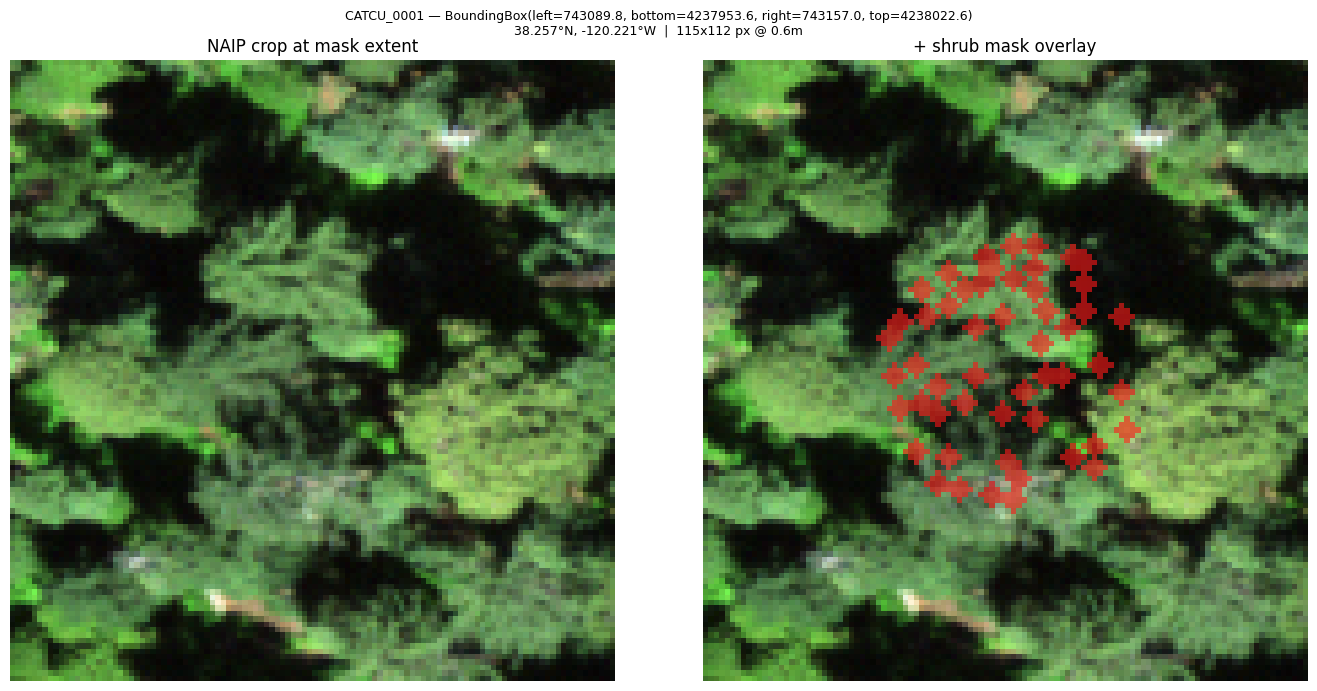

In [18]:
with rasterio.open(mask_path) as msrc:
    mask_bounds = msrc.bounds
    mask = msrc.read(1).astype(float)
    nodata = msrc.nodata

if nodata is not None:
    mask = np.where(mask == nodata, np.nan, mask)

# Check mask is inside NAIP
with rasterio.open(naip_path) as nsrc:
    nb = nsrc.bounds
    inside = (mask_bounds.left   >= nb.left  and
              mask_bounds.right  <= nb.right and
              mask_bounds.bottom >= nb.bottom and
              mask_bounds.top    <= nb.top)
    print(f"Mask inside NAIP bounds: {inside}")

    # Read only the NAIP window that corresponds to the mask extent
    win = from_bounds(*mask_bounds, transform=nsrc.transform)
    rgb = nsrc.read([1, 2, 3], window=win).astype(float)

# Normalize
for i in range(3):
    b = rgb[i]
    rgb[i] = (b - b.min()) / (b.max() - b.min() + 1e-9)
rgb_display = np.moveaxis(rgb, 0, -1)

# Resize mask to match the cropped NAIP window pixel size
from skimage.transform import resize
mask_resized = resize(mask, (rgb_display.shape[0], rgb_display.shape[1]), order=0, preserve_range=True)

overlay = np.zeros((*mask_resized.shape, 4), dtype=float)
overlay[mask_resized == 1] = [1.0, 0.1, 0.1, 0.6]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(rgb_display)
axes[0].set_title("NAIP crop at mask extent")
axes[0].axis("off")

axes[1].imshow(rgb_display)
axes[1].imshow(overlay)
axes[1].set_title("+ shrub mask overlay")
axes[1].axis("off")

plt.suptitle(f"CATCU_0001 — {mask_bounds}\n38.257°N, -120.221°W  |  {mask.shape[0]}x{mask.shape[1]} px @ 0.6m", fontsize=9)
plt.tight_layout()
plt.show()

GENERAL SUMMARY
Number of masks: 299
Number of sites: 6

NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
width,299.0,107.648829,6.332013,82.00,105.00,109.00,112.00,117.00
height,299.0,107.852843,6.213626,79.00,105.00,110.00,112.00,117.00
shrub_pixels,299.0,305.143813,133.469284,39.00,191.50,307.00,397.00,662.00
bg_pixels,299.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
total_valid_pixels,299.0,305.143813,133.469284,39.00,191.50,307.00,397.00,662.00
shrub_area_m2,299.0,109.851773,48.048942,14.04,68.94,110.52,142.92,238.32
total_area_m2,299.0,109.851773,48.048942,14.04,68.94,110.52,142.92,238.32
shrub_fraction,299.0,1.000000,0.000000,1.00,1.00,1.00,1.00,1.00
n_points,299.0,24.066890,10.604017,3.00,15.00,24.00,32.00,53.00



SITE SUMMARY


,site_folder,n_masks,shrub_fraction_mean,shrub_fraction_median,shrub_fraction_min,shrub_fraction_max,shrub_area_m2_mean,shrub_area_m2_median,shrub_area_m2_min,shrub_area_m2_max,total_area_m2_mean,total_area_m2_median,n_points_mean,n_points_median,n_points_min,n_points_max
0,calaveras-big-trees,73,1.0,1.0,1.0,1.0,119.061370,121.32,32.76,237.24,119.061370,121.32,25.986301,26.0,7,52
1,dl-bliss,27,1.0,1.0,1.0,1.0,98.173333,97.56,53.28,167.04,98.173333,97.56,21.814815,22.0,12,37
2,independence-lake,56,1.0,1.0,1.0,1.0,74.275714,59.58,28.08,238.32,74.275714,59.58,16.232143,13.0,6,53
3,pacific-union-college,37,1.0,1.0,1.0,1.0,115.229189,113.40,42.12,207.36,115.229189,113.40,25.243243,25.0,9,46
4,sedgwick,83,1.0,1.0,1.0,1.0,122.512771,126.00,14.04,201.60,122.512771,126.00,26.855422,28.0,3,44
5,shaver-lake,23,1.0,1.0,1.0,1.0,126.610435,124.20,56.16,200.52,126.610435,124.20,27.739130,27.0,12,44



TOP 10 LARGEST SHRUB AREAS


,site_folder,mask_name,shrub_area_m2,shrub_fraction,width,height,n_points
125,independence-lake,CATNF_6041_20240814_1_mask.tif,238.32,1.0,114,115,53
0,calaveras-big-trees,CATCU_0001_20240923_1_mask.tif,237.24,1.0,112,115,52
134,independence-lake,CATNF_6050_20240812_1_mask.tif,235.44,1.0,111,117,52
21,calaveras-big-trees,CATCU_0043_20241023_1_mask.tif,221.76,1.0,114,113,48
47,calaveras-big-trees,CATCU_0081_20250612_1_mask.tif,213.48,1.0,115,114,47
44,calaveras-big-trees,CATCU_0077_20250515_1_mask.tif,212.76,1.0,110,115,48
163,pacific-union-college,CALNU_0010_20250805_1_mask.tif,207.36,1.0,114,115,46
149,independence-lake,CATNF_6109_20250819_1_mask.tif,203.04,1.0,113,113,45
5,calaveras-big-trees,CATCU_0006_20240926_1_mask.tif,201.60,1.0,113,115,44
221,sedgwick,CASBC_0029_20240912_1_mask.tif,201.60,1.0,113,112,44



TOP 10 SMALLEST SHRUB AREAS


,site_folder,mask_name,shrub_area_m2,shrub_fraction,width,height,n_points
244,sedgwick,CASBC_0053_20241117_1_mask.tif,14.04,1.0,87,101,3
237,sedgwick,CASBC_0046_20241117_1_mask.tif,23.40,1.0,109,93,5
133,independence-lake,CATNF_6049_20240813_1_mask.tif,28.08,1.0,111,94,6
107,independence-lake,CATNF_6009_20240731_1_mask.tif,28.08,1.0,110,100,6
123,independence-lake,CATNF_6025_20240731_1_mask.tif,31.32,1.0,89,109,7
116,independence-lake,CATNF_6018_20240731_1_mask.tif,32.40,1.0,93,107,7
102,independence-lake,CATNF_6004_20240731_1_mask.tif,32.76,1.0,93,108,7
66,calaveras-big-trees,CATCU_0219_20250514_1_mask.tif,32.76,1.0,91,108,7
144,independence-lake,CATNF_6066_20240815_1_mask.tif,36.00,1.0,98,97,8
65,calaveras-big-trees,CATCU_0218_20250514_1_mask.tif,36.00,1.0,99,100,8


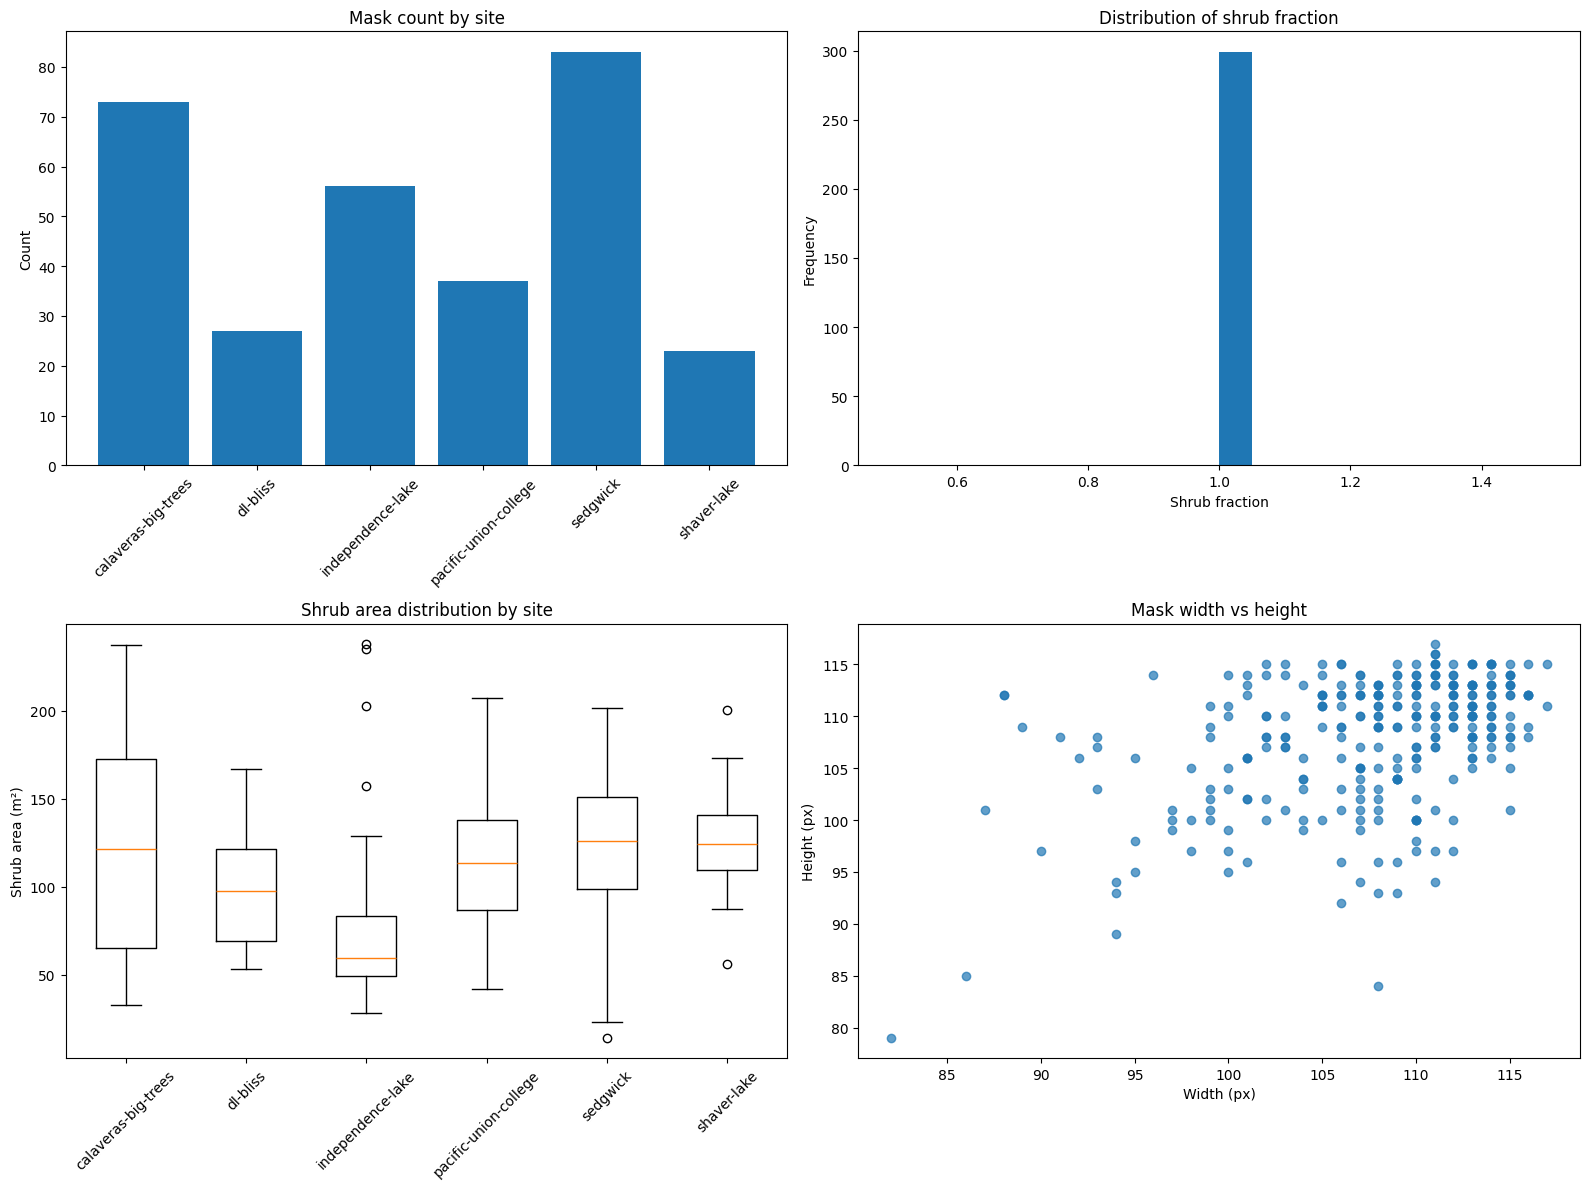

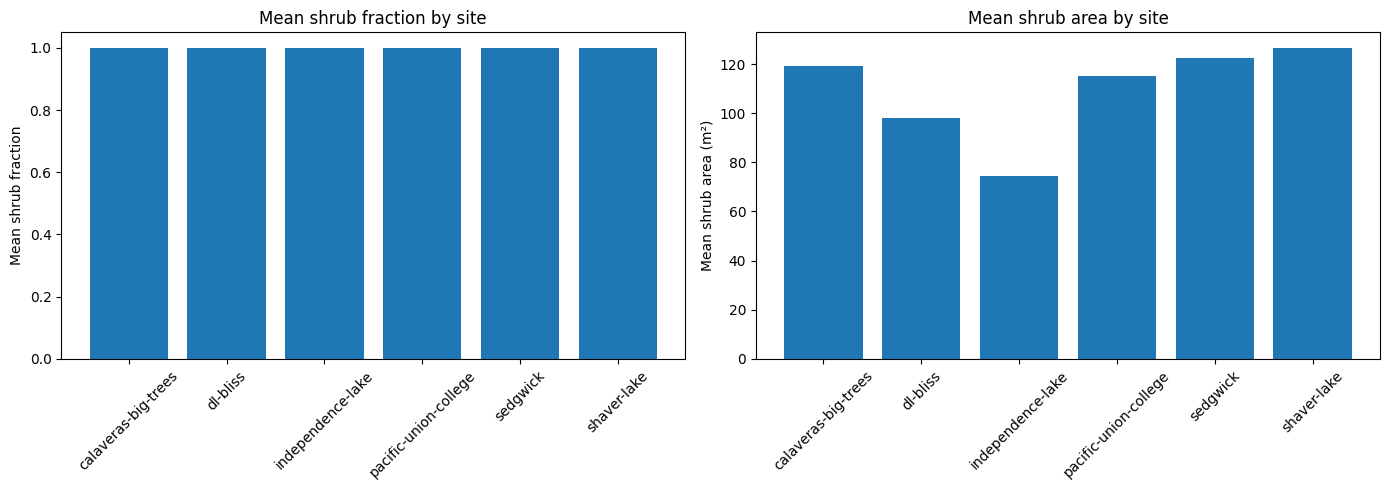


SITE AGGREGATED TABLE


,site_folder,mean_shrub_fraction,mean_shrub_area_m2,median_shrub_area_m2,n_masks
5,shaver-lake,1.0,126.610435,124.20,23
4,sedgwick,1.0,122.512771,126.00,83
0,calaveras-big-trees,1.0,119.061370,121.32,73
3,pacific-union-college,1.0,115.229189,113.40,37
1,dl-bliss,1.0,98.173333,97.56,27
2,independence-lake,1.0,74.275714,59.58,56


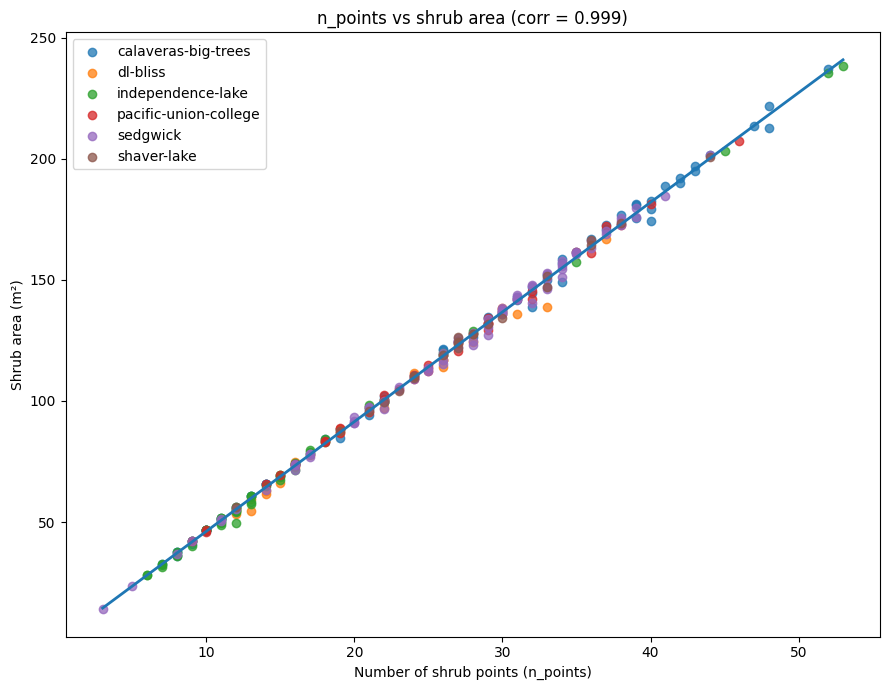

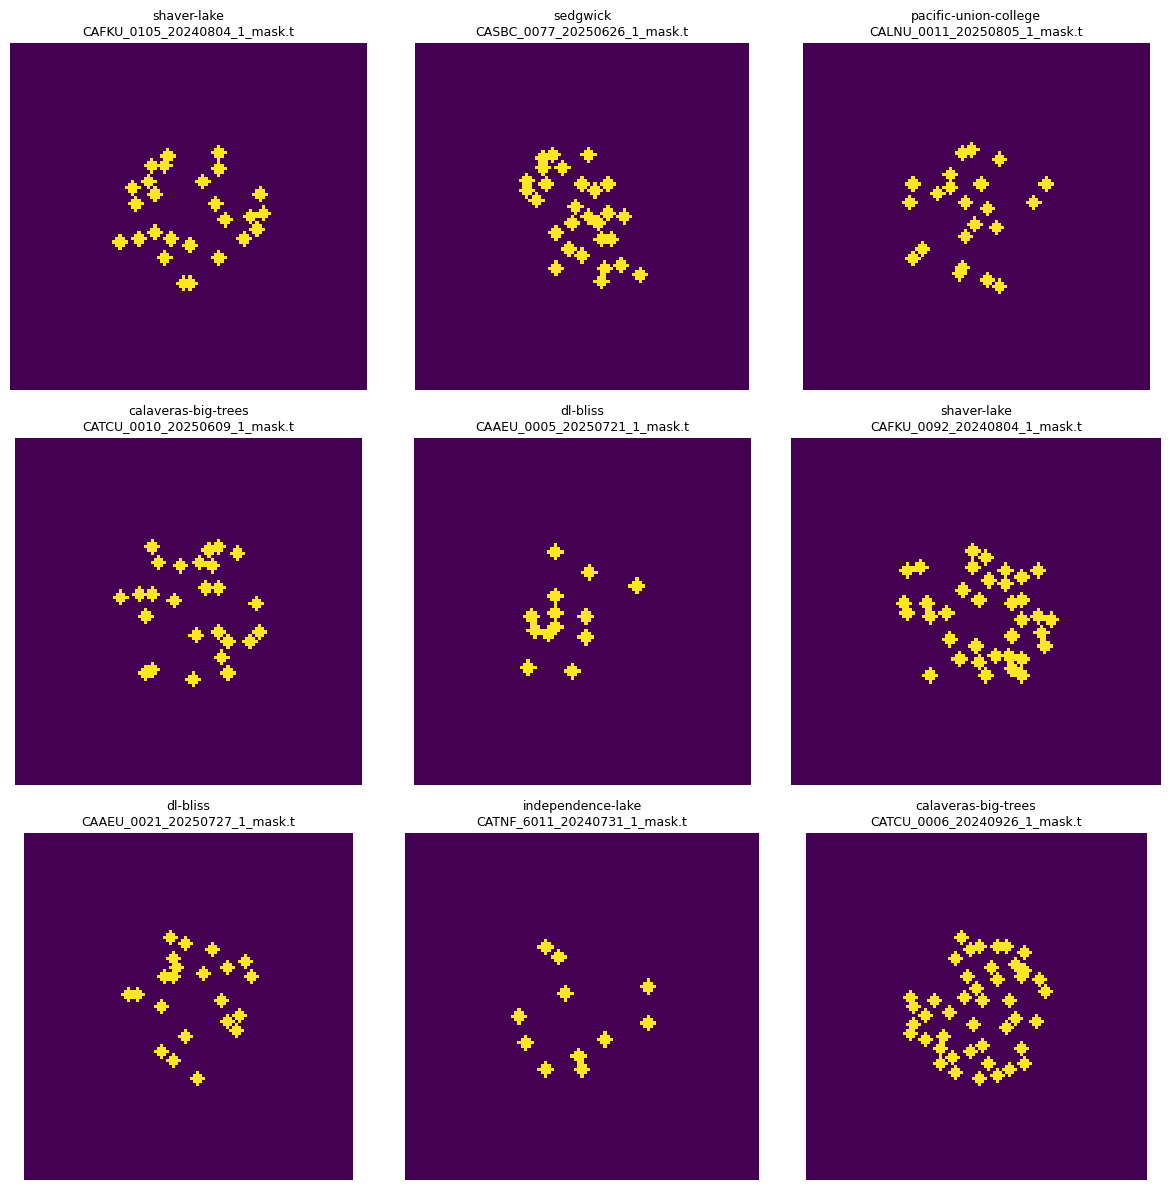


DONE: statistics and plots created successfully.


In [20]:


from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0) CHECK REQUIRED VARIABLES
# ---------------------------------------------------------
if "OUTPUT_ROOT" not in globals():
    raise ValueError("OUTPUT_ROOT is not defined. Run the main notebook cells first.")

summary_csv = OUTPUT_ROOT / "mask_generation_summary.csv"

# ---------------------------------------------------------
# 1) LOAD SUMMARY TABLE
# ---------------------------------------------------------
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    summary_df = results_df.copy()
elif summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
else:
    raise ValueError("Neither results_df nor mask_generation_summary.csv was found.")

# ---------------------------------------------------------
# 2) READ ALL GENERATED MASKS AND EXTRACT STATS
# ---------------------------------------------------------
mask_files = sorted(OUTPUT_ROOT.rglob("*_mask.tif"))

if len(mask_files) == 0:
    raise ValueError(f"No *_mask.tif files found under {OUTPUT_ROOT}")

rows = []
for fp in mask_files:
    try:
        with rasterio.open(fp) as src:
            arr = src.read(1)
            nodata = src.nodata

            if nodata is not None:
                valid_mask = arr != nodata
                arr_valid = arr[valid_mask]
            else:
                arr_valid = arr

            if arr_valid.size == 0:
                continue

            shrub_pixels = int(np.sum(arr_valid == 1))
            bg_pixels = int(np.sum(arr_valid == 0))
            total_valid = int(arr_valid.size)

            px_w = abs(src.transform.a)
            px_h = abs(src.transform.e)
            pixel_area_m2 = px_w * px_h

            shrub_area_m2 = shrub_pixels * pixel_area_m2
            total_area_m2 = total_valid * pixel_area_m2
            shrub_fraction = shrub_pixels / total_valid if total_valid > 0 else np.nan

            rows.append({
                "mask_path": str(fp),
                "mask_name": fp.name,
                "site_folder": fp.parent.name,
                "width": src.width,
                "height": src.height,
                "pixel_size_x": px_w,
                "pixel_size_y": px_h,
                "pixel_area_m2": pixel_area_m2,
                "shrub_pixels": shrub_pixels,
                "bg_pixels": bg_pixels,
                "total_valid_pixels": total_valid,
                "shrub_area_m2": shrub_area_m2,
                "total_area_m2": total_area_m2,
                "shrub_fraction": shrub_fraction
            })
    except Exception as e:
        print(f"Skipped {fp.name}: {e}")

mask_stats_df = pd.DataFrame(rows)

if mask_stats_df.empty:
    raise ValueError("No valid mask statistics could be extracted.")

# ---------------------------------------------------------
# 3) MERGE WITH SUMMARY TABLE IF POSSIBLE
# ---------------------------------------------------------
merged_df = mask_stats_df.copy()

if "mask_path" in summary_df.columns:
    summary_df = summary_df.copy()
    summary_df["mask_name"] = summary_df["mask_path"].astype(str).apply(lambda x: Path(x).name)

    merged_df = pd.merge(
        mask_stats_df,
        summary_df,
        on="mask_name",
        how="left",
        suffixes=("_mask", "_summary")
    )

# ---------------------------------------------------------
# 4) PRINT MAIN SUMMARY
# ---------------------------------------------------------
print("=" * 70)
print("GENERAL SUMMARY")
print("=" * 70)
print(f"Number of masks: {len(merged_df)}")
print(f"Number of sites: {merged_df['site_folder'].nunique()}")

summary_cols = [
    c for c in [
        "width", "height", "shrub_pixels", "bg_pixels", "total_valid_pixels",
        "shrub_area_m2", "total_area_m2", "shrub_fraction", "n_points"
    ] if c in merged_df.columns
]

print("\nNUMERIC SUMMARY")
display(merged_df[summary_cols].describe().T)

# ---------------------------------------------------------
# 5) SITE-BASED SUMMARY
# ---------------------------------------------------------
agg_dict = {
    "mask_name": "count",
    "shrub_fraction": ["mean", "median", "min", "max"],
    "shrub_area_m2": ["mean", "median", "min", "max"],
    "total_area_m2": ["mean", "median"]
}

if "n_points" in merged_df.columns:
    agg_dict["n_points"] = ["mean", "median", "min", "max"]

site_summary = merged_df.groupby("site_folder").agg(agg_dict)
site_summary.columns = ["_".join(col).strip() for col in site_summary.columns.values]
site_summary = site_summary.rename(columns={"mask_name_count": "n_masks"}).reset_index()

print("\nSITE SUMMARY")
display(site_summary)

# ---------------------------------------------------------
# 6) TOP / BOTTOM MASKS
# ---------------------------------------------------------
cols_show = ["site_folder", "mask_name", "shrub_area_m2", "shrub_fraction", "width", "height"]
if "n_points" in merged_df.columns:
    cols_show.append("n_points")

print("\nTOP 10 LARGEST SHRUB AREAS")
display(merged_df.sort_values("shrub_area_m2", ascending=False)[cols_show].head(10))

print("\nTOP 10 SMALLEST SHRUB AREAS")
display(merged_df.sort_values("shrub_area_m2", ascending=True)[cols_show].head(10))

# ---------------------------------------------------------
# 7) MULTI-PANEL PLOTS
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mask count by site
site_counts = merged_df["site_folder"].value_counts().sort_index()
axes[0, 0].bar(site_counts.index, site_counts.values)
axes[0, 0].set_title("Mask count by site")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=45)

# Plot 2: Shrub fraction histogram
axes[0, 1].hist(merged_df["shrub_fraction"].dropna(), bins=20)
axes[0, 1].set_title("Distribution of shrub fraction")
axes[0, 1].set_xlabel("Shrub fraction")
axes[0, 1].set_ylabel("Frequency")

# Plot 3: Shrub area boxplot by site
sites = sorted(merged_df["site_folder"].dropna().unique())
box_data = [merged_df.loc[merged_df["site_folder"] == s, "shrub_area_m2"].dropna() for s in sites]
axes[1, 0].boxplot(box_data, tick_labels=sites, vert=True)
axes[1, 0].set_title("Shrub area distribution by site")
axes[1, 0].set_ylabel("Shrub area (m²)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Plot 4: Width vs Height
axes[1, 1].scatter(merged_df["width"], merged_df["height"], alpha=0.7)
axes[1, 1].set_title("Mask width vs height")
axes[1, 1].set_xlabel("Width (px)")
axes[1, 1].set_ylabel("Height (px)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8) SITE MEAN COMPARISON
# ---------------------------------------------------------
site_agg = merged_df.groupby("site_folder", as_index=False).agg(
    mean_shrub_fraction=("shrub_fraction", "mean"),
    mean_shrub_area_m2=("shrub_area_m2", "mean"),
    median_shrub_area_m2=("shrub_area_m2", "median"),
    n_masks=("mask_name", "count")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(site_agg["site_folder"], site_agg["mean_shrub_fraction"])
axes[0].set_title("Mean shrub fraction by site")
axes[0].set_ylabel("Mean shrub fraction")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(site_agg["site_folder"], site_agg["mean_shrub_area_m2"])
axes[1].set_title("Mean shrub area by site")
axes[1].set_ylabel("Mean shrub area (m²)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nSITE AGGREGATED TABLE")
display(site_agg.sort_values("mean_shrub_area_m2", ascending=False))

# ---------------------------------------------------------
# 9) N_POINTS VS SHRUB AREA (IF AVAILABLE)
# ---------------------------------------------------------
if "n_points" in merged_df.columns:
    df_scatter = merged_df.dropna(subset=["n_points", "shrub_area_m2"]).copy()

    if len(df_scatter) > 0:
        plt.figure(figsize=(9, 7))

        for site in sorted(df_scatter["site_folder"].dropna().unique()):
            sub = df_scatter[df_scatter["site_folder"] == site]
            plt.scatter(sub["n_points"], sub["shrub_area_m2"], alpha=0.75, label=site)

        if len(df_scatter) >= 2:
            x = df_scatter["n_points"].to_numpy(dtype=float)
            y = df_scatter["shrub_area_m2"].to_numpy(dtype=float)
            coef = np.polyfit(x, y, 1)
            xline = np.linspace(x.min(), x.max(), 200)
            yline = coef[0] * xline + coef[1]
            plt.plot(xline, yline, linewidth=2)

            corr = np.corrcoef(x, y)[0, 1]
            plt.title(f"n_points vs shrub area (corr = {corr:.3f})")
        else:
            plt.title("n_points vs shrub area")

        plt.xlabel("Number of shrub points (n_points)")
        plt.ylabel("Shrub area (m²)")
        plt.legend()
        plt.tight_layout()
        plt.show()

# ---------------------------------------------------------
# ---------------------------------------------------------
# 10) SAMPLE MASK GALLERY
# ---------------------------------------------------------
if "mask_path" in merged_df.columns:
    path_col = "mask_path"
elif "mask_path_mask" in merged_df.columns:
    path_col = "mask_path_mask"
elif "mask_path_summary" in merged_df.columns:
    path_col = "mask_path_summary"
else:
    raise ValueError(f"No mask path column found. Available columns: {list(merged_df.columns)}")

n_samples = min(9, len(merged_df))
sample_df = merged_df.sample(n=n_samples, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(sample_df):
        row = sample_df.iloc[i]
        with rasterio.open(row[path_col]) as src:
            arr = src.read(1)
        ax.imshow(arr)
        ax.set_title(f"{row['site_folder']}\n{row['mask_name'][:28]}", fontsize=9)
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

print("\nDONE: statistics and plots created successfully.")